# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [21]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import pandas as pd

## Creamos la sesión de spark

In [22]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [23]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [24]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [25]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [26]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


---
## Ejercicios sobre los datos agregados
Leemos los datos guardados en Parquet y trabajamos sobre ellos.

In [27]:
datos_agregados = spark.read.parquet("resultados/")
print(f"Registros cargados: {datos_agregados.count()}")
datos_agregados.show(5, truncate=False)

Registros cargados: 40
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|window                                    |sensor_id|avg_value         |avg_temp          |avg_humidity     |num_events|
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|{2026-02-06 22:47:00, 2026-02-06 22:47:30}|S1       |27.2825           |57.09             |54.0125          |4         |
|{2026-02-06 22:47:00, 2026-02-06 22:47:30}|S4       |12.97             |57.76             |22.83            |1         |
|{2026-02-06 22:47:00, 2026-02-06 22:47:30}|S3       |20.66333333333333 |61.32666666666666 |38.36666666666667|3         |
|{2026-02-06 22:47:30, 2026-02-06 22:48:00}|S1       |30.020000000000003|65.95             |44.6225          |8         |
|{2026-02-06 22:47:30, 2026-02-06 22:48:00}|S4       |34.50714285714285 |59.638571428571424|53.38571428571429|7         |
+

### Ejercicio 1: Exploración inicial
Muestra el esquema, cuenta filas y sensores distintos.

In [28]:
datos_agregados.printSchema()

total_registros = datos_agregados.count()
print(f"Total de filas: {total_registros}")

cantidad_sensores = datos_agregados.select("sensor_id").distinct().count()
print(f"Sensores distintos: {cantidad_sensores}")

datos_agregados.select("sensor_id").distinct().orderBy("sensor_id").show()

root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

Total de filas: 40
Sensores distintos: 4
+---------+
|sensor_id|
+---------+
|       S1|
|       S2|
|       S3|
|       S4|
+---------+



### Ejercicio 2: Transformaciones numéricas
Crea una columna nueva a partir de métricas existentes y calcula min, max y media.

In [29]:
tabla_con_ratio = datos_agregados.withColumn("ratio_temp_hum", col("avg_temp") / col("avg_humidity"))

estadisticas = tabla_con_ratio.select(
    F.min("ratio_temp_hum").alias("minimo"),
    F.max("ratio_temp_hum").alias("maximo"),
    F.avg("ratio_temp_hum").alias("media")
).collect()[0]

print("=== RATIO TEMPERATURA / HUMEDAD ===")
if estadisticas['minimo'] is not None:
    print(f"Minimo: {estadisticas['minimo']:.2f}")
    print(f"Maximo: {estadisticas['maximo']:.2f}")
    print(f"Media: {estadisticas['media']:.2f}")
else:
    print("No hay datos disponibles")

tabla_con_ratio.select("sensor_id", "avg_temp", "avg_humidity", "ratio_temp_hum").show(10)

=== RATIO TEMPERATURA / HUMEDAD ===
Minimo: 0.73
Maximo: 2.53
Media: 1.15
+---------+------------------+------------------+------------------+
|sensor_id|          avg_temp|      avg_humidity|    ratio_temp_hum|
+---------+------------------+------------------+------------------+
|       S1|             57.09|           54.0125|  1.05697755149271|
|       S4|             57.76|             22.83|2.5300043802014893|
|       S3| 61.32666666666666| 38.36666666666667|1.5984361424847957|
|       S1|             65.95|           44.6225| 1.477953946999832|
|       S4|59.638571428571424| 53.38571428571429| 1.117126036928017|
|       S3| 55.82142857142857|             50.85|1.0977665402444163|
|       S1|50.308749999999996|53.713750000000005|0.9366084103232412|
|       S4|50.492000000000004|41.114999999999995| 1.228067615225587|
|       S3| 60.96125000000001|          57.86125| 1.053576443647519|
|       S1|49.857142857142854| 53.86285714285715|0.9256312327604496|
+---------+------------------

### Ejercicio 3: Filtrado avanzado
Filtra por humedad, número de eventos y sensor. ¿Cuántos registros cumplen todas las condiciones?

In [30]:
registros_filtrados = datos_agregados.filter(
    (col("avg_humidity") > 45) &
    (col("num_events") >= 20) &
    (col("sensor_id").isin(["S2", "S4"]))
)

coincidencias = registros_filtrados.count()
total = datos_agregados.count()
print(f"Registros que cumplen las condiciones: {coincidencias}")
if total > 0:
    print(f"Porcentaje del total: {(coincidencias / total) * 100:.2f}%")

registros_filtrados.show(10)

Registros que cumplen las condiciones: 0
Porcentaje del total: 0.00%
+------+---------+---------+--------+------------+----------+
|window|sensor_id|avg_value|avg_temp|avg_humidity|num_events|
+------+---------+---------+--------+------------+----------+
+------+---------+---------+--------+------------+----------+



### Ejercicio 4: Agregaciones por sensor
Agrupa por sensor_id y obtén estadísticas. ¿Qué sensor tiene mayor media? ¿Y temperatura máxima?

In [31]:
estadisticas_por_sensor = datos_agregados.groupBy("sensor_id").agg(
    F.avg("avg_value").alias("valor_medio"),
    F.max("avg_value").alias("valor_max"),
    F.avg("avg_temp").alias("temp_media"),
    F.max("avg_temp").alias("temp_max"),
    F.avg("avg_humidity").alias("hum_media"),
    F.count("*").alias("ventanas")
).orderBy("sensor_id")

estadisticas_por_sensor.show(truncate=False)

sensor_mayor_valor = estadisticas_por_sensor.orderBy(col("valor_medio").desc()).first()
if sensor_mayor_valor:
    print(f"Sensor con mayor media de valor: {sensor_mayor_valor['sensor_id']} ({sensor_mayor_valor['valor_medio']:.2f})")

sensor_mas_caliente = estadisticas_por_sensor.orderBy(col("temp_max").desc()).first()
if sensor_mas_caliente:
    print(f"Sensor con temperatura maxima: {sensor_mas_caliente['sensor_id']} ({sensor_mas_caliente['temp_max']:.2f})")

print("\nVentanas por sensor:")
estadisticas_por_sensor.select("sensor_id", "ventanas").show()

+---------+------------------+------------------+-----------------+------------------+------------------+--------+
|sensor_id|valor_medio       |valor_max         |temp_media       |temp_max          |hum_media         |ventanas|
+---------+------------------+------------------+-----------------+------------------+------------------+--------+
|S1       |29.03666865079365 |35.3875           |57.25543452380953|65.95             |54.85240873015873 |10      |
|S2       |32.70372380952381 |39.286            |55.40415396825398|70.78571428571429 |52.65678730158729 |10      |
|S3       |28.770957142857146|33.565714285714286|56.44492976190476|61.410000000000004|51.368163095238096|10      |
|S4       |27.871559235209237|34.50714285714285 |57.65194906204906|65.12             |47.64072572150072 |10      |
+---------+------------------+------------------+-----------------+------------------+------------------+--------+

Sensor con mayor media de valor: S2 (32.70)
Sensor con temperatura maxima: S2 (

### Ejercicio 5: Ranking con funciones de ventana
Usa funciones de ventana para encontrar el registro con mayor avg_value por sensor.

In [32]:
ventana_por_sensor = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

tabla_con_posiciones = datos_agregados.withColumn("posicion", F.rank().over(ventana_por_sensor))

mejores_por_sensor = tabla_con_posiciones.filter(col("posicion") == 1)

mejores_por_sensor.select(
    "sensor_id", "window", "avg_value", "avg_temp", "avg_humidity"
).orderBy("sensor_id").show(truncate=False)

el_mejor = mejores_por_sensor.orderBy(col("avg_value").desc()).first()
if el_mejor:
    print(f"Sensor con valor maximo global: {el_mejor['sensor_id']}")
    print(f"Valor: {el_mejor['avg_value']:.2f}")

+---------+------------------------------------------+------------------+------------------+------------------+
|sensor_id|window                                    |avg_value         |avg_temp          |avg_humidity      |
+---------+------------------------------------------+------------------+------------------+------------------+
|S1       |{2026-02-06 22:49:30, 2026-02-06 22:50:00}|35.3875           |60.0925           |54.63125          |
|S2       |{2026-02-06 22:48:00, 2026-02-06 22:48:30}|39.286            |54.477999999999994|54.370000000000005|
|S3       |{2026-02-06 22:50:00, 2026-02-06 22:50:30}|33.565714285714286|50.82             |54.74             |
|S4       |{2026-02-06 22:47:30, 2026-02-06 22:48:00}|34.50714285714285 |59.638571428571424|53.38571428571429 |
+---------+------------------------------------------+------------------+------------------+------------------+

Sensor con valor maximo global: S2
Valor: 39.29


### Ejercicio 6: Join con tabla auxiliar
Crea un DataFrame con info adicional de sensores y haz un join. Muestra los 5 primeros registros.

In [33]:
catalogo_sensores = [
    ("S1", "Nave A", "Temperatura", 2021),
    ("S2", "Oficina B", "Humedad", 2022),
    ("S3", "Nave C", "Presion", 2020),
    ("S4", "Almacen D", "Temperatura", 2023)
]

esquema_catalogo = StructType([
    StructField("sensor_id", StringType()),
    StructField("lugar", StringType()),
    StructField("tipo", StringType()),
    StructField("anno", IntegerType())
])

tabla_catalogo = spark.createDataFrame(catalogo_sensores, esquema_catalogo)
tabla_catalogo.show()

tabla_completa = datos_agregados.join(tabla_catalogo, "sensor_id", "left")

tabla_completa.select(
    "sensor_id", "lugar", "tipo", "avg_value", "avg_temp", "avg_humidity"
).show(5, truncate=False)

+---------+---------+-----------+----+
|sensor_id|    lugar|       tipo|anno|
+---------+---------+-----------+----+
|       S1|   Nave A|Temperatura|2021|
|       S2|Oficina B|    Humedad|2022|
|       S3|   Nave C|    Presion|2020|
|       S4|Almacen D|Temperatura|2023|
+---------+---------+-----------+----+

+---------+---------+-----------+-----------------+------------------+-----------------+
|sensor_id|lugar    |tipo       |avg_value        |avg_temp          |avg_humidity     |
+---------+---------+-----------+-----------------+------------------+-----------------+
|S4       |Almacen D|Temperatura|12.97            |57.76             |22.83            |
|S4       |Almacen D|Temperatura|34.50714285714285|59.638571428571424|53.38571428571429|
|S3       |Nave C   |Presion    |20.66333333333333|61.32666666666666 |38.36666666666667|
|S3       |Nave C   |Presion    |28.51285714285714|55.82142857142857 |50.85            |
|S1       |Nave A   |Temperatura|27.2825          |57.09        

### Ejercicio 7: Agrupación por ventana temporal
Extrae el inicio de la ventana, trunca a minuto y agrupa. ¿Cuántas ventanas y qué humedad media hay por minuto?

In [34]:
datos_con_tiempo = datos_agregados.withColumn("inicio_ventana", col("window.start"))
datos_con_tiempo = datos_con_tiempo.withColumn("minuto", F.date_trunc("minute", col("inicio_ventana")))

agrupado_por_minuto = datos_con_tiempo.groupBy("minuto").agg(
    F.count("*").alias("ventanas"),
    F.avg("avg_humidity").alias("hum_media"),
    F.avg("avg_temp").alias("temp_media")
).orderBy("minuto")

agrupado_por_minuto.show(20, truncate=False)

total_minutos = agrupado_por_minuto.count()
humedad_promedio_total = agrupado_por_minuto.agg(F.avg("hum_media")).collect()[0][0]
print(f"Minutos distintos: {total_minutos}")
if humedad_promedio_total is not None:
    print(f"Humedad media general: {humedad_promedio_total:.2f}%")

+-------------------+--------+------------------+------------------+
|minuto             |ventanas|hum_media         |temp_media        |
+-------------------+--------+------------------+------------------+
|2026-02-06 22:47:00|8       |48.34217261904762 |56.439529761904765|
|2026-02-06 22:48:00|8       |51.781482142857136|53.74632142857142 |
|2026-02-06 22:49:00|8       |52.88817410714286 |55.78672123015873 |
|2026-02-06 22:50:00|8       |53.45570526695527 |57.07649981962482 |
|2026-02-06 22:51:00|8       |51.68007192460318 |60.39651190476191 |
+-------------------+--------+------------------+------------------+

Minutos distintos: 5
Humedad media general: 51.63%


### Ejercicio 8: Repartición y particiones
Reparte el DataFrame por sensor_id y muestra la distribución de registros entre particiones.

In [35]:
numero_particiones = 4
tabla_repartida = datos_agregados.repartition(numero_particiones, "sensor_id")
tabla_con_particion = tabla_repartida.withColumn("id_particion", F.spark_partition_id())

print(f"Numero de particiones: {tabla_con_particion.rdd.getNumPartitions()}")

tabla_con_particion.groupBy("id_particion").agg(
    F.count("*").alias("registros"),
    F.collect_set("sensor_id").alias("sensores")
).orderBy("id_particion").show(truncate=False)

tabla_con_particion.select("id_particion", "sensor_id", "avg_value").show(10)

Numero de particiones: 4
+------------+---------+--------+
|id_particion|registros|sensores|
+------------+---------+--------+
|0           |10       |[S3]    |
|1           |20       |[S2, S4]|
|3           |10       |[S1]    |
+------------+---------+--------+

+------------+---------+------------------+
|id_particion|sensor_id|         avg_value|
+------------+---------+------------------+
|           0|       S3| 20.66333333333333|
|           0|       S3| 28.51285714285714|
|           0|       S3|28.305000000000003|
|           0|       S3|31.610000000000003|
|           0|       S3|33.565714285714286|
|           0|       S3|31.914285714285715|
|           0|       S3| 33.18666666666667|
|           0|       S3|             30.65|
|           0|       S3|21.145999999999997|
|           0|       S3|28.155714285714286|
+------------+---------+------------------+
only showing top 10 rows



### Ejercicio 9: Detección de anomalías
Define criterios de anomalía. ¿Cuántos registros son anómalos? ¿Qué sensor tiene más?

In [36]:
promedio_valor = datos_agregados.agg(F.avg("avg_value")).collect()[0][0]
desviacion_valor = datos_agregados.agg(F.stddev("avg_value")).collect()[0][0]

if promedio_valor is not None and desviacion_valor is not None:
    print(f"Media de avg_value: {promedio_valor:.2f}")
    print(f"Desviacion estandar: {desviacion_valor:.2f}")

    tabla_con_anomalias = datos_agregados.withColumn(
        "anomalia",
        F.when(
            (F.abs(col("avg_value") - promedio_valor) > 2 * desviacion_valor) |
            (col("avg_temp") > 75) |
            (col("avg_humidity") < 30) |
            (col("num_events") < 10),
            True
        ).otherwise(False)
    )

    total_anomalos = tabla_con_anomalias.filter(col("anomalia") == True).count()
    total = datos_agregados.count()
    print(f"\nRegistros anomalos: {total_anomalos}")
    if total > 0:
        print(f"Porcentaje: {(total_anomalos / total) * 100:.2f}%")

    tabla_con_anomalias.filter(col("anomalia") == True).groupBy("sensor_id").count().orderBy(col("count").desc()).show()

    sensor_problematico = tabla_con_anomalias.filter(col("anomalia") == True).groupBy("sensor_id").count().orderBy(col("count").desc()).first()
    if sensor_problematico:
        print(f"Sensor con mas anomalias: {sensor_problematico['sensor_id']} ({sensor_problematico['count']})")
else:
    print("No hay datos disponibles para detectar anomalias")

Media de avg_value: 29.60
Desviacion estandar: 4.68

Registros anomalos: 35
Porcentaje: 87.50%
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S1|   10|
|       S3|    9|
|       S2|    9|
|       S4|    7|
+---------+-----+

Sensor con mas anomalias: S1 (10)


### Ejercicio 10: Cruce de métricas
Crea una puntuación ponderada combinando avg_value, temperatura y humedad.

In [37]:
tabla_con_nota = datos_agregados.withColumn(
    "puntuacion",
    (col("avg_value") * 0.5) + 
    (col("avg_temp") * 0.25) + 
    (col("avg_humidity") * 0.15) + 
    (col("num_events") * 0.1)
)

registro_ganador = tabla_con_nota.orderBy(col("puntuacion").desc()).first()
if registro_ganador:
    print(f"Sensor con mayor puntuacion: {registro_ganador['sensor_id']}")
    print(f"Puntuacion: {registro_ganador['puntuacion']:.2f}")

tabla_con_nota.select(
    "sensor_id", "puntuacion", "avg_value", "avg_temp", "avg_humidity"
).orderBy(col("puntuacion").desc()).show(10)

tabla_con_nota.groupBy("sensor_id").agg(
    F.avg("puntuacion").alias("punt_media"),
    F.max("puntuacion").alias("punt_max")
).orderBy(col("punt_media").desc()).show()

Sensor con mayor puntuacion: S2
Puntuacion: 42.64
+---------+------------------+------------------+------------------+------------------+
|sensor_id|        puntuacion|         avg_value|          avg_temp|      avg_humidity|
+---------+------------------+------------------+------------------+------------------+
|       S2| 42.63971428571429|35.097142857142856| 70.78571428571429| 44.63142857142857|
|       S2|41.918000000000006|            39.286|54.477999999999994|54.370000000000005|
|       S4|        41.8296875|29.547500000000003|             65.12| 66.50625000000001|
|       S1|        41.7115625|           35.3875|           60.0925|          54.63125|
|       S4|40.871071428571426| 34.50714285714285|59.638571428571424| 53.38571428571429|
|       S2|40.485499999999995|33.998000000000005|60.763999999999996| 51.96999999999999|
|       S3|40.282500000000006| 33.18666666666667| 60.13666666666668| 53.70000000000001|
|       S4|           40.1439|            32.374|            60.842|  

### Ejercicio 11: Gráficos con matplotlib
Convierte a pandas y genera dos gráficos sobre las variables del DataFrame.

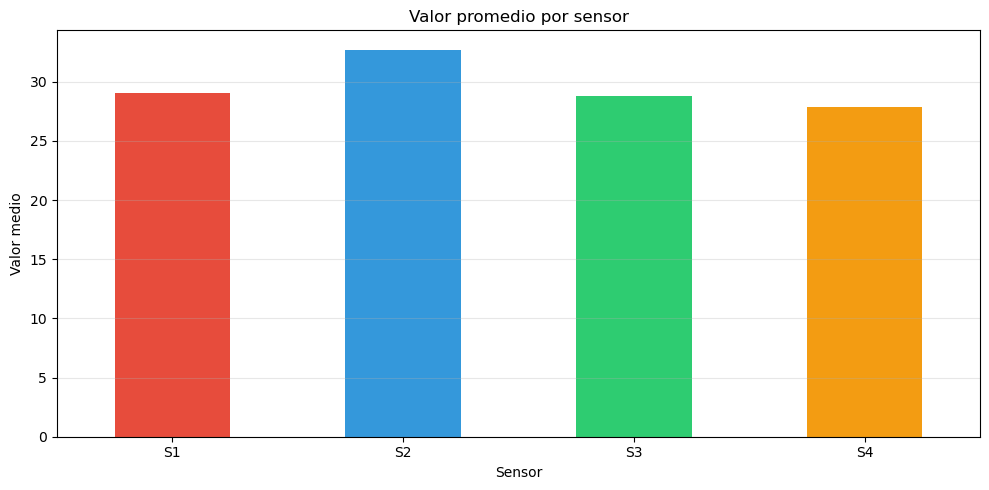

In [38]:
tabla_pandas = datos_agregados.select("sensor_id", "avg_value", "avg_temp", "avg_humidity").toPandas()

plt.figure(figsize=(10, 5))
promedios_sensor = tabla_pandas.groupby("sensor_id")["avg_value"].mean()
promedios_sensor.plot(kind="bar", color=["#e74c3c", "#3498db", "#2ecc71", "#f39c12"])
plt.title("Valor promedio por sensor")
plt.xlabel("Sensor")
plt.ylabel("Valor medio")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

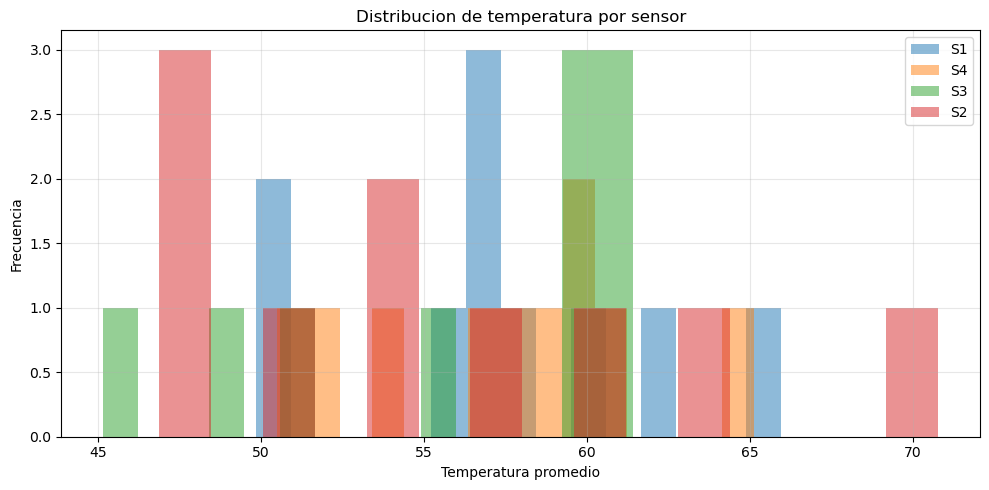

In [39]:
plt.figure(figsize=(10, 5))
for sid in tabla_pandas["sensor_id"].unique():
    subset = tabla_pandas[tabla_pandas["sensor_id"] == sid]
    plt.hist(subset["avg_temp"], bins=15, alpha=0.5, label=sid)

plt.title("Distribucion de temperatura por sensor")
plt.xlabel("Temperatura promedio")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()